In [ ]:
import torch   
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F 


In [2]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

with_cuda = torch.cuda.is_available()
if with_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import os
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import random_split, DataLoader, Dataset

In [4]:
def normalization(x,mini , maxi):
    return (x - mini) / (maxi - mini)

def denormalization(x ,mini , maxi):
    return x * (maxi - mini) + mini

In [5]:
print(device)

cuda


In [6]:
class SpectrogramDataset(Dataset):
    def __init__(self, spec_path):
        self.file_paths = [os.path.join(spec_path, f)
                           for f in os.listdir(spec_path) if f.endswith('.npy')]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        log_spectrogram = np.load(self.file_paths[idx])
        log_spectrogram_tensor = torch.from_numpy(log_spectrogram).float()
        mini, maxi = log_spectrogram_tensor.min(), log_spectrogram_tensor.max()
        normalize_tensor = (log_spectrogram_tensor - mini) / (maxi - mini + 1e-8)
        return normalize_tensor, mini, maxi

def get_loader(spec_path, batch_size=5):
    dataset = SpectrogramDataset(spec_path)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def get_data(spec_path, batch_size= 12 , split_ratio=0.8):
    dataset = SpectrogramDataset(spec_path)
    train_size = int(split_ratio * len(dataset))
    test_size = len(dataset) - train_size

    # Split aléatoire du dataset
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    # Création des DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) #numworkers = 4
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


In [ ]:
train_loader, test_loader = get_data("C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\spec")

maxim = 0
minim = np.inf
for input_, mini, maxi in train_loader:
    mini = min(mini)
    maxi = max(maxi)
    if maxi > maxim:
        maxim = maxi.item()
    if mini < minim:
        minim = mini.item()
        
print(maxim)
print(minim)

53.74848175048828
-42.4544563293457


In [8]:
def train_loader(spec_path, minim, maxim, batch_size=5):
    specs = []

    for fichier in os.listdir(spec_path):
        if fichier.endswith(".npy"):
            path = os.path.join(spec_path, fichier)
            spec = np.load(path)
            spec_tensor = torch.from_numpy(spec).float()

            # Normalisation globale
            spec_norm = (spec_tensor - minim) / (maxim - minim)
            specs.append(spec_norm)

    # Stack en batchs
    dataset = torch.utils.data.TensorDataset(torch.stack(specs))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    return loader


In [9]:
class RNN_autoencoder(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=500): #800 bien pour spec
        super(RNN_autoencoder, self).__init__()
        self.encoder = nn.RNN(input_dim, hidden_dim,  num_layers=1 , batch_first=True)
        self.decoder = nn.RNN(hidden_dim, hidden_dim, num_layers=1 , batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)        
        
    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(1, batch_size, 500).to(x.device)
        latent, h_enc = self.encoder(x, h0)
        output, _ = self.decoder(latent, h_enc)
        output2 = self.output_layer(output)  # final projection
        return output2


In [ ]:
class RNN_VAE_erreur(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=600, latent_dim=500):
        super(RNN_VAE_erreur, self).__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        
        
        
        # Encoder
        
        self.encoder = nn.RNN(input_dim, hidden_dim, num_layers=1, batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Projeter z vers un nouvel état caché
        self.fc_decode = nn.Linear(latent_dim, hidden_dim)

        # Decoder
        self.decoder = nn.RNN(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        
        batch_size = x.size(0)

        h0_enc = torch.zeros(1, batch_size, self.hidden_dim).to(x.device)

        # Encoder RNN
        latent_seq, hidden_enc = self.encoder(x, h0_enc) # hidden_enc a la forme : (1, batch, hidden_dim) latent_seq a la forme (batch, seq_len, hidden_dim)
        return latent_seq, hidden_enc
    
    def decode(self, mu, logvar, latent_seq):
        
        batch_size , seq_len, _ = latent_seq.size() # (B, seq_len, hidden_dim)
        
        z = self.reparameterize(mu, logvar)        # (B, latent_dim)

        # Transformer z en état caché du décodeur
        h0_dec = self.fc_decode(z).unsqueeze(0)    # (1, B, hidden_dim)
        
        decoder_input = torch.zeros(batch_size, seq_len, self.hidden_dim).to(device)
        decoded_seq, _ = self.decoder(decoder_input, h0_dec)
        
        output = self.output_layer(decoded_seq)
        return output

    
    
    def forward(self, x):
        
        latent_seq, hidden_enc = self.encode(x) 

        # z ~ N(mu, sigma)
        mu = self.fc_mu(hidden_enc.squeeze(0))     # (B, latent_dim)
        logvar = self.fc_logvar(hidden_enc.squeeze(0)) # (B, latent_dim)
        
        mu = torch.clamp(mu, min=-5, max=5)
        logvar = torch.clamp(logvar, min=-5, max=5)

        output = self.decode(mu, logvar, latent_seq) # (B, seq_len, input_dim)
        
        return output, mu, logvar
        
    def sample(self, num_samples, seq_len=2000, device=device):
        
        with torch.no_grad():
            # Tirage de z aléatoires
            z = torch.randn(num_samples, self.latent_dim).to(device)

            # Projection de z vers un hidden state pour initialiser le décodeur
            h0_dec = self.fc_decode(z).unsqueeze(0)  # (1, B, hidden_dim)

            # Entrée vide (tout à zéro) pour le décodeur
            decoder_input = torch.zeros(num_samples, seq_len, self.hidden_dim).to(device)

            # Décodage
            decoded_seq, _ = self.decoder(decoder_input, h0_dec)
            output = self.output_layer(decoded_seq)  # (B, seq_len, input_dim)

            return output

    def sample_autoregressive(self, num_samples, seq_len, device):
        
        with torch.no_grad():
            # Tirage aléatoire dans l’espace latent
            z = torch.randn(num_samples, self.latent_dim).to(device)

            # Transformation de z → état caché initial pour le décodeur
            h_dec = self.fc_decode(z).unsqueeze(0)  # (1, num_samples, hidden_dim)

            # Entrée initiale vide (souvent un vecteur nul)
            input_t = torch.zeros(num_samples, 1, self.hidden_dim).to(device)

            outputs = []

            for _ in range(seq_len):
                out, h_dec = self.decoder(input_t, h_dec)  # RNN: pas de c_dec
                out_frame = self.output_layer(out)         # (num_samples, 1, input_dim)
                outputs.append(out_frame)

                input_t = out  # ou out_frame (selon si tu veux feedback du latent ou de la sortie)

            return torch.cat(outputs, dim=1)  # (num_samples, seq_len, input_dim)
    
    def reconstruct(self, x):
        pass # a faire 


In [ ]:
class RNN_VAE_chunks(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=600, latent_dim=500):
        super(RNN_VAE_chunks, self).__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.fc = nn.Linear(latent_dim, 128 * 8 * 16)  # taille de départ = (128, 8, 16)

        
        
        # Encoder
        
        self.encoder = nn.RNN(input_dim, hidden_dim, num_layers=1, batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8x16 → 16x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 16x32 → 32x64
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),   # 32x64 → 64x128
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=1), # 64x128 → 128x256
            )


    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        
        batch_size = x.size(0)

        h0_enc = torch.zeros(1, batch_size, self.hidden_dim).to(x.device)

        # Encoder RNN
        latent_seq, hidden_enc = self.encoder(x, h0_enc) # hidden_enc a la forme : (1, batch, hidden_dim) latent_seq a la forme (batch, seq_len, hidden_dim)
        return latent_seq, hidden_enc
    

    def decode(self, mu, logvar, latent_seq):
        B_chunks, _ = mu.size()
        chunks_per_seq = 2000 // latent_seq.size(1)  # chunk_len supposé connu

        B = B_chunks // chunks_per_seq
        chunks_per_seq = int(chunks_per_seq)
        
        # Regrouper les mu/logvar par séquence
        mu = mu.view(B, chunks_per_seq, -1).mean(dim=1)
        logvar = logvar.view(B, chunks_per_seq, -1).mean(dim=1)

        z = self.reparameterize(mu, logvar)  # (B, latent_dim)
        
        # Projeter en volume 4D
        x = self.fc(z)              # (B, 128*8*16)
        x = x.view(B, 128, 8, 16)   # (B, 128, 8, 16)
        out = self.deconv(x)        # (B, 1, 1024, 2048) approximatif

        # Ajuster/crop pour obtenir exactement (1025, 2000)
        out = F.interpolate(out, size=(1025, 2000), mode='bilinear', align_corners=False)

        return out.squeeze(1)  # (B, 1025, 2000)

    
    def forward(self, x):
        
        latent_seq, hidden_enc = self.encode(x) 

        # z ~ N(mu, sigma)
        mu = self.fc_mu(hidden_enc.squeeze(0))     # (B, latent_dim)
        logvar = self.fc_logvar(hidden_enc.squeeze(0)) # (B, latent_dim)
        
        """mu = torch.clamp(mu, min=-5, max=5)
        logvar = torch.clamp(logvar, min=-5, max=5)"""

        output = self.decode(mu, logvar, latent_seq) # (B, seq_len, input_dim)
        
        return output, mu, logvar
        
    def sample(self, num_samples, seq_len=2000, device=device):
        
        with torch.no_grad():
            # Tirage de z aléatoires
            z = torch.randn(num_samples, self.latent_dim).to(device)

            # Projection de z vers un hidden state pour initialiser le décodeur
            h0_dec = self.fc_decode(z).unsqueeze(0)  # (1, B, hidden_dim)

            # Entrée vide (tout à zéro) pour le décodeur
            decoder_input = torch.zeros(num_samples, seq_len, self.hidden_dim).to(device)

            # Décodage
            decoded_seq, _ = self.decoder(decoder_input, h0_dec)
            output = self.output_layer(decoded_seq)  # (B, seq_len, input_dim)

            return output

    def sample_autoregressive(self, num_samples, seq_len, device):
        
        with torch.no_grad():
            # Tirage aléatoire dans l’espace latent
            z = torch.randn(num_samples, self.latent_dim).to(device)

            # Transformation de z → état caché initial pour le décodeur
            h_dec = self.fc_decode(z).unsqueeze(0)  # (1, num_samples, hidden_dim)

            # Entrée initiale vide (souvent un vecteur nul)
            input_t = torch.zeros(num_samples, 1, self.hidden_dim).to(device)

            outputs = []

            for _ in range(seq_len):
                out, h_dec = self.decoder(input_t, h_dec)  # RNN: pas de c_dec
                out_frame = self.output_layer(out)         # (num_samples, 1, input_dim)
                outputs.append(out_frame)

                input_t = out  # ou out_frame (selon si tu veux feedback du latent ou de la sortie)

            return torch.cat(outputs, dim=1)  # (num_samples, seq_len, input_dim)
    
    def reconstruct(self, x):
        pass # a faire 


In [ ]:
class RNN_VAE(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=600, latent_dim=500):
        super(RNN_VAE, self).__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.fc = nn.Linear(latent_dim, 128 * 32 * 16)  # taille de départ = (128, 8, 16)

        
        
        # Encoder
        
        self.encoder = nn.RNN(input_dim, hidden_dim, num_layers=1, batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.deconv = nn.Sequential(
            # [12, 128, 16, 32] -> [12, 64, 32, 64]
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # [12, 64, 32, 64] -> [12, 32, 64, 128]
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # [12, 32, 64, 128] -> [12, 16, 128, 256]
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # [12, 16, 128, 256] -> [12, 8, 256, 512]
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # [12, 8, 256, 512] -> [12, 4, 512, 1024]
            nn.ConvTranspose2d(8, 4, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # [12, 4, 512, 1024] -> [12, 1, 1024, 2048]
            nn.ConvTranspose2d(4, 1, kernel_size=4, stride=2, padding=1),
        )


    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        
        batch_size = x.size(0)

        h0_enc = torch.zeros(1, batch_size, self.hidden_dim).to(x.device)

        # Encoder RNN
        latent_seq, hidden_enc = self.encoder(x, h0_enc) # hidden_enc a la forme : (1, batch, hidden_dim) latent_seq a la forme (batch, seq_len, hidden_dim)
        return latent_seq, hidden_enc
    

    def decode(self, mu, logvar):
        

        z = self.reparameterize(mu, logvar)  # (B, latent_dim)
        batch_size = z.size(0)
        # Projeter en volume 4D
        x = self.fc(z)              # (B, 128*8*16)
 
        x = x.view(batch_size, 128, 16, 32)   # (B, 128, 8, 16)
      
        out = self.deconv(x)        # (B, 1, 1024, 2048) approximatif
        
        # Ajuster/crop pour obtenir exactement (1025, 2000)
        out = F.interpolate(out, size=(1025, 2000), mode='bilinear', align_corners=False)

        return out.squeeze(1)  # (B, 1025, 2000)

    
    def forward(self, x):
        
        latent_seq, hidden_enc = self.encode(x) 

        # z ~ N(mu, sigma)
        mu = self.fc_mu(hidden_enc.squeeze(0))     # (B, latent_dim)
        logvar = self.fc_logvar(hidden_enc.squeeze(0)) # (B, latent_dim)
        
        """mu = torch.clamp(mu, min=-5, max=5)
        logvar = torch.clamp(logvar, min=-5, max=5)"""

        output = self.decode(mu, logvar) # (B, seq_len, input_dim)
        
        return output, mu, logvar
        
    def sample(self, num_samples, seq_len=2000, device=device):
        
        with torch.no_grad():
            # Tirage de z aléatoires
            z = torch.randn(num_samples, self.latent_dim).to(device)

            batch_size = z.size(0)
            # Projeter en volume 4D
            x = self.fc(z)              # (B, 128*8*16)
    
            x = x.view(batch_size, 128, 16, 32)   # (B, 128, 8, 16)
        
            out = self.deconv(x)        # (B, 1, 1024, 2048) approximatif
            
            # Ajuster/crop pour obtenir exactement (1025, 2000)
            out = F.interpolate(out, size=(1025, 2000), mode='bilinear', align_corners=False)

            return out
    
    def reconstruct(self, x):
        pass # a faire 


In [13]:
class GRU_VAE(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=600, latent_dim=500, batch_size=12):
        super(GRU_VAE, self).__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.batch_size = batch_size

        # Encoder GRU
        self.encoder = nn.GRU(input_dim, hidden_dim, num_layers=1, batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decode z into hidden state
        self.fc_decode = nn.Linear(latent_dim, hidden_dim)

        # Decoder GRU
        self.decoder = nn.GRU(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        batch_size = x.size(0)
        h0_enc = torch.zeros(1, batch_size, self.hidden_dim).to(x.device)

        # Encoder GRU
        latent_seq, hidden_enc = self.encoder(x, h0_enc)  # hidden_enc: (1, B, H)

        # z ~ N(mu, sigma)
        mu = self.fc_mu(hidden_enc.squeeze(0))
        logvar = self.fc_logvar(hidden_enc.squeeze(0))
        mu = torch.clamp(mu, min=-5, max=5)
        logvar = torch.clamp(logvar, min=-5, max=5)
        z = self.reparameterize(mu, logvar)

        # z → état caché du décodeur
        h0_dec = self.fc_decode(z).unsqueeze(0)  # (1, B, H)

        # Decoder avec latent_seq comme input
        decoded_seq, _ = self.decoder(latent_seq, h0_dec)
        output = self.output_layer(decoded_seq)

        return output, mu, logvar

    def sample(self, num_samples, seq_len=2000, device='cuda'):
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim).to(device)
            h0_dec = self.fc_decode(z).unsqueeze(0)
            decoder_input = torch.zeros(num_samples, seq_len, self.hidden_dim).to(device)
            decoded_seq, _ = self.decoder(decoder_input, h0_dec)
            output = self.output_layer(decoded_seq)
            return output

    def sample_autoregressive(self, num_samples, seq_len, device):
        with torch.no_grad():
            # Tirage aléatoire dans l’espace latent
            z = torch.randn(num_samples, self.latent_dim).to(device)

            # Transformation de z → état caché initial pour le décodeur
            h_dec = self.fc_decode(z).unsqueeze(0)  # (1, num_samples, hidden_dim)

            # Entrée initiale vide (souvent un vecteur nul)
            input_t = torch.zeros(num_samples, 1, self.hidden_dim).to(device)

            outputs = []

            for _ in range(seq_len):
                out, h_dec = self.decoder(input_t, h_dec)  # RNN: pas de c_dec
                out_frame = self.output_layer(out)         # (num_samples, 1, input_dim)
                outputs.append(out_frame)

                input_t = out  # ou out_frame (selon si tu veux feedback du latent ou de la sortie)

            return torch.cat(outputs, dim=1)  # (num_samples, seq_len, input_dim)

        
    def reconstruct(self, x):
        with torch.no_grad():
            batch_size = x.size(0)
            h0_enc = torch.zeros(1, batch_size, self.hidden_dim).to(x.device)
            latent_seq, hidden_enc = self.encoder(x, h0_enc)


In [14]:
import torch
print(torch.__version__)           # Version de PyTorch
print(torch.version.cuda)          # Version CUDA liée à PyTorch (None = CPU-only)
print(torch.backends.cudnn.version())  # Version cuDNN

2.6.0+cu126
12.6
90501


In [15]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [16]:
def split_sequence2(input_tensor, chunk_len=200): 
    # input_tensor: (batch, 1025, 2000)
    input_tensor = input_tensor.permute(0, 2, 1)  # (batch, time, freq) = (B, 2000, 1025)
    batch, total_len, feat = input_tensor.shape
    num_chunks = total_len // chunk_len
    input_tensor = input_tensor[:, :num_chunks * chunk_len, :]  # truncate
    chunks = input_tensor.reshape(batch * num_chunks, chunk_len, feat)  # (B*num_chunks, chunk_len, feat)
    return chunks

def split_sequence(input_tensor, chunk_len=200):# faut que 2000 soit un multiple de chunk_len
    # input_tensor: (batch, 1025, 2000)
    input_tensor = input_tensor.permute(0, 2, 1)  # (batch, time, freq) = (B, 2000, 1025)
    batch, total_len, feat = input_tensor.shape
    num_chunks = total_len // chunk_len

    input_tensor = input_tensor.contiguous().view(batch*num_chunks, chunk_len, feat)  
    return input_tensor
#marche pas à changer reflechir 

In [ ]:
def testeur(data_loader, model, device , epoch , loss_test, loss_affichage, recon_loss_plot , kl_loss_plot, mu_plot,logvar_plot , logvar_std_plot, mu_std_plot , minim, maxim):
    path = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\images_Rnn_VAE"
    
    
    plt.figure(figsize=(10, 4))
    plt.plot(kl_loss_plot, label='KL Divergence Loss', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('KL Divergence Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(path + "\\loss", f"loss_reconstruction_kl_{epoch}epochs.png"))
    plt.close()
    
    plt.figure(figsize=(10, 4))
    plt.plot(recon_loss_plot, label='Reconstruction Loss', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('KL Divergence Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(path + "\\loss", f"loss_reconstruction_{epoch}epochs.png"))
    plt.close()
    
    plt.figure(figsize=(10, 4))
    plt.plot(mu_plot, label='mu', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('mu Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(path + "\\loss", f"mu_moy{epoch}epochs.png"))
    plt.close()
    
    plt.figure(figsize=(10, 4))
    plt.plot(logvar_plot, label='logvar', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('logvar Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(path + "\\loss", f"logvar_moy{epoch}epochs.png"))
    plt.close()
    
    plt.figure(figsize=(10, 4))
    plt.plot(logvar_std_plot, label='logvar', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('logvar_std Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(path + "\\loss", f"logvar_std{epoch}epochs.png"))
    plt.close()
    
    plt.figure(figsize=(10, 4))
    plt.plot(mu_std_plot, label='logvar', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('mu_std Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(path + "\\loss", f"mu_std{epoch}epochs.png"))
    plt.close()
    
    original = data_loader.dataset[8]
    original = original.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Reconstruction
        original_input = original.permute(0, 2, 1)  # (1, 2000, 1025)
        reconstructed, mu, logvar = model(original_input)  # 👈 changement ici
        reconstructed = reconstructed.permute(0, 2, 1) 
    
   

    original = original.squeeze(0).cpu().detach().numpy()
    reconstructed = reconstructed.squeeze(0).cpu().detach().numpy()


    original = denormalization(original, minim, maxim)

    reconstructed2 = denormalization(reconstructed, minim, maxim)
        
        
    def save_audio_original(path, spec, epoch):
        # Enregistrer le fichier audio
        audio_path = os.path.join(path + "\\son", f"audio_original.wav")
        spec_amp = librosa.db_to_amplitude(spec)
        signal = librosa.griffinlim(spec_amp, hop_length=512)
        sf.write(audio_path, signal, 22050)
         
    
    def save_audio_reconstructed(path, spec, epoch):
        # Enregistrer le fichier audio
        audio_path = os.path.join(path + "\\son", f"audio_reconstruit{epoch}.wav")
        spec_amp = librosa.db_to_amplitude(spec)
        signal = librosa.griffinlim(spec_amp, hop_length=512)

        sf.write(audio_path, signal, 22050)

    def save_image_original(path, image, epoch):
        # Enregistrer l'image
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(image, y_axis='log', x_axis='time')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"{image} : {epoch}")
        img_path = os.path.join(path + "\\images" , "images_original.png")
        plt.savefig(img_path)
        plt.close()

    def save_image_reconstruit(path, image, epoch):
        # Enregistrer l'image
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(image, y_axis='log', x_axis='time')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"{image} : {epoch}")
        img_path = os.path.join(path + "\\images", f"images_reconstuites{epoch}.png")
        plt.savefig(img_path)
        plt.close()
    
    save_audio_original(path, original, epoch)
    save_audio_reconstructed(path, reconstructed2, epoch)
    save_image_original(path, original, epoch)
    save_image_reconstruit(path, reconstructed2, epoch)
    
    if epoch > 0 : 
        plt.figure(figsize=(10, 4))
        train = list(range(len(loss_affichage)))         # [0, 1, 2, ..., 49]
        test = list(range(0, epoch+1 , 10))   # [0, 10, 20, 30, 40]
   
        # 2. Les courbes
        plt.plot(train, loss_affichage, label='Train Loss', color='blue')
        plt.plot(test, loss_test, label='Test Loss', color='orange', marker='o')

        # 3. Habillage
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Train vs Test Loss')
        plt.legend()
        plt.grid(True)

        # 4. Sauvegarde
        plt.savefig(os.path.join(path + "\\loss", f"loss_comparaison_{epoch}epochs.png"))
        plt.close()

    
    if epoch > 30 : 
        loss__test_tronque = loss_test[1:]
        loss_affichage_tronque = loss_affichage[10:]
        plt.figure(figsize=(10, 4))
        train = list(range(len(loss_affichage_tronque)))         # [0, 1, 2, ..., 49]
        test = list(range(0, epoch, 10))   # [0, 10, 20, 30, 40]

        # 2. Les courbes
        plt.plot(train, loss_affichage_tronque, label='Train Loss', color='blue')
        plt.plot(test, loss__test_tronque, label='Test Loss', color='orange', marker='o')

        # 3. Habillage
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Train vs Test Loss')
        plt.legend()
        plt.grid(True)

        # 4. Sauvegarde
        plt.savefig(os.path.join(path + "\\loss", f"loss_comparaison_tronque.png"))
        plt.close()
        
    
    

In [18]:
class SpectrogramDataset(Dataset):
    def __init__(self, spec_path, minim, maxim):
        self.file_paths = [os.path.join(spec_path, f)
                           for f in os.listdir(spec_path) if f.endswith('.npy')]
        self.minim = minim
        self.maxim = maxim

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        spec = np.load(self.file_paths[idx])
        spec_tensor = torch.from_numpy(spec).float()
        spec_norm = (spec_tensor - self.minim) / (self.maxim - self.minim)
        return spec_norm

def get_data(spec_path, minim, maxim, batch_size=12, split_ratio=0.8):
    dataset = SpectrogramDataset(spec_path, minim, maxim)
    train_size = int(split_ratio * len(dataset))
    test_size = len(dataset) - train_size

    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader



In [19]:
from torch.amp import GradScaler
from torch.amp import autocast



In [ ]:
def train_model_rnn_avec_chunks(data_loader,test_loader, model, criterion, optimizer, nepochs, device, minim ,maxim, chunk_len=200, scheduler=None):

    scaler = GradScaler(device='cuda')
    loss_affichage = []
    max = np.inf
    loss_test = []
    recon_loss_plot = []
    kl_loss_plot = []
    mu_plot = []
    logvar_plot = []
    logvar_std_plot = []
    mu_std_plot = []
    for epoch in range(nepochs):
        train_loss = 0
        model.train()
        for batch_idx, input_ in enumerate(tqdm(data_loader, desc=f"Epoch {epoch}")):
            input_ = input_.to(device)  # shape: (batch, 1025, 2000)
            
            # Découpage en petits morceaux
            chunks = split_sequence(input_, chunk_len=chunk_len)  # (B', chunk_len, 1025) me coupe la musique en plein de morceaux de 200

            optimizer.zero_grad()
            with autocast('cuda'):  # 👈 Ici, on fait tout en float16 sauf exceptions
                recon, mu, logvar = model(chunks)
                
                
                loss , recon_loss, kl_loss = criterion(recon, input_, mu ,logvar,epoch)
    
            scaler.scale(loss).backward()

            # 💥 Clip des gradients pour éviter explosion
            scaler.unscale_(optimizer)  # Obligatoire avant clip avec AMP
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
            recon_loss_plot.append(recon_loss.detach().cpu().item())
            kl_loss_plot.append(kl_loss.detach().cpu().item())
            mu_plot.append(mu.mean().detach().cpu().item())
            logvar_plot.append(logvar.mean().detach().cpu().item())
            logvar_std_plot.append(logvar.std().detach().cpu().item())
            mu_std_plot.append(mu.std().detach().cpu().item())
            """loss.backward()
            optimizer.step()"""

            train_loss += loss.detach().cpu().item()
            
            if max > loss.item():
                max = loss.item() 
                torch.save(model.state_dict(), "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\images_Rnn_VAE\\modele\\best_modele.pth")
            '''if batch_idx % 40 == 0:
                print(f"Batch {batch_idx}: Loss = {loss.item():.6f}")'''
        avg_loss = train_loss / len(data_loader)
        loss_affichage.append(avg_loss)	
        print(f"Epoch {epoch}: Training loss = {avg_loss:.6f}")
        
        if scheduler is not None:
            scheduler.step(avg_loss)
        
        if epoch % 10 == 0:
            test_loss = 0
            model.eval()
            
            with torch.no_grad():
                for batch_idx, input_ in enumerate(test_loader):
                    input_ = input_.to(device)
                    chunks = split_sequence(input_, chunk_len=chunk_len)
                    recon, mu, logvar = model(chunks)
                    loss, recon_loss, kl_loss = criterion(recon, input_,mu , logvar,epoch)
                    test_loss += loss.detach().cpu().item()
                loss_test.append(test_loss/len(test_loader))
                print(f"Test loss = {test_loss/len(test_loader):.6f}")
            testeur(data_loader, model, device , epoch, loss_test , loss_affichage ,recon_loss_plot , kl_loss_plot, mu_plot , logvar_plot,  logvar_std_plot, mu_std_plot ,minim , maxim)  
            


In [ ]:
def train_model_rnn(data_loader,test_loader, model, criterion, optimizer, nepochs, device, minim ,maxim, chunk_len=200, scheduler=None):

    scaler = GradScaler(device='cuda')
    loss_affichage = []
    max = np.inf
    loss_test = []
    recon_loss_plot = []
    kl_loss_plot = []
    mu_plot = []
    logvar_plot = []
    logvar_std_plot = []
    mu_std_plot = []
    for epoch in range(nepochs):
        train_loss = 0
        model.train()
        for batch_idx, input_ in enumerate(tqdm(data_loader, desc=f"Epoch {epoch}")):
            input_ = input_.to(device)  # shape: (batch, 1025, 2000)
            input2 = input_.permute(0, 2, 1)  # (batch, 2000, 1025)
            optimizer.zero_grad()
            with autocast('cuda'):  # 👈 Ici, on fait tout en float16 sauf exceptions
                recon, mu, logvar = model(input2)
                
                
                loss , recon_loss, kl_loss = criterion(recon, input_, mu ,logvar,epoch)
    
            scaler.scale(loss).backward()

            # 💥 Clip des gradients pour éviter explosion
            scaler.unscale_(optimizer)  # Obligatoire avant clip avec AMP
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
            recon_loss_plot.append(recon_loss.detach().cpu().item())
            kl_loss_plot.append(kl_loss.detach().cpu().item())
            mu_plot.append(mu.mean().detach().cpu().item())
            logvar_plot.append(logvar.mean().detach().cpu().item())
            logvar_std_plot.append(logvar.std().detach().cpu().item())
            mu_std_plot.append(mu.std().detach().cpu().item())
            """loss.backward()
            optimizer.step()"""

            train_loss += loss.detach().cpu().item()
            
            if max > loss.item():
                max = loss.item() 
                torch.save(model.state_dict(), "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\images_Rnn_VAE\\modele\\best_modele.pth")
            '''if batch_idx % 40 == 0:
                print(f"Batch {batch_idx}: Loss = {loss.item():.6f}")'''
        avg_loss = train_loss / len(data_loader)
        loss_affichage.append(avg_loss)	
        print(f"Epoch {epoch}: Training loss = {avg_loss:.6f}")
        
        if scheduler is not None:
            scheduler.step(avg_loss)
        
        if epoch % 10 == 0:
            test_loss = 0
            model.eval()
            
            with torch.no_grad():
                for batch_idx, input_ in enumerate(test_loader):
                    input_ = input_.to(device)
                    input2 = input_.permute(0, 2, 1)  # (batch, 2000, 1025)
                    recon, mu, logvar = model(input2)
                    loss, recon_loss, kl_loss = criterion(recon, input_,mu , logvar,epoch)
                    test_loss += loss.detach().cpu().item()
                loss_test.append(test_loss/len(test_loader))
                print(f"Test loss = {test_loss/len(test_loader):.6f}")
            testeur(data_loader, model, device , epoch, loss_test , loss_affichage ,recon_loss_plot , kl_loss_plot, mu_plot , logvar_plot,  logvar_std_plot, mu_std_plot ,minim , maxim)  
            


In [22]:
def vae_loss_fn(recon, x, mu, logvar,epoch):
    # Stabilisation avec log1p
    """recon = torch.clamp(recon, min=-0.99)
    x = torch.clamp(x, min=-0.99)"""
    recon = torch.log1p(recon)
    x = torch.log1p(x)
    """beta = min(1.0, epoch / 50)  # ou un autre planning"""
    beta = 1
    # Reconstruction loss
    recon_loss = F.mse_loss(recon, x, reduction='mean')

    # KL divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # Total loss
    total_loss = recon_loss + beta*kl_loss
    return total_loss , recon_loss, kl_loss


In [ ]:

#criterion = auraloss.freq.MultiResolutionSTFTLoss() # a tester e profondeur
#criterion = nn.MSELoss()  #avant
from torch.optim.lr_scheduler import ReduceLROnPlateau


criterion = vae_loss_fn 
model_rnn = RNN_VAE().to(device)
model_gru = GRU_VAE(input_dim=1025, hidden_dim=1024, latent_dim=128, batch_size=12).to(device)
model = RNN_autoencoder().to(device)
"""model = MusicRNNVAE(input_dim=1025, hidden_dim=1024, latent_dim=128, num_layers=2).to(device)"""
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=0.0006) # 0.0005 bien pour tout_spec et RNN vae

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=4, verbose=True)



train_loader, test_loader = get_data("C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\spec", minim, maxim, batch_size=12, split_ratio=0.8)

train_model_rnn(train_loader, test_loader, model_rnn, criterion, optimizer, minim = minim , maxim = maxim, nepochs=31, device=device, scheduler=scheduler)


c:\Users\gabri\anaconda3\envs\gab\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 0: 100%|██████████| 14/14 [00:08<00:00,  1.67it/s]


Epoch 0: Training loss = 0.161196
Test loss = 0.140626


Epoch 1: 100%|██████████| 14/14 [00:08<00:00,  1.67it/s]


Epoch 1: Training loss = 0.123342


Epoch 2: 100%|██████████| 14/14 [00:12<00:00,  1.13it/s]


...

Epoch 28: Training loss = 0.009857


Epoch 29: 100%|██████████| 14/14 [00:05<00:00,  2.52it/s]


Epoch 29: Training loss = 0.009647


Epoch 30: 100%|██████████| 14/14 [00:06<00:00,  2.22it/s]


Epoch 30: Training loss = 0.010343
Test loss = 0.011207


In [24]:
# tester le decode_autoregressive ?
# reajuster le beta 

In [ ]:
best_mod = model_rnn.load_state_dict(torch.load("C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\images_Rnn_VAE\\modele\\best_modele.pth"))
model_rnn.eval()

images = model_rnn.sample(2, 2000, device=device)
for im in images:
    print(im.shape)
    
    
    

torch.Size([1, 1025, 2000])
torch.Size([1, 1025, 2000])


(1025, 2000)


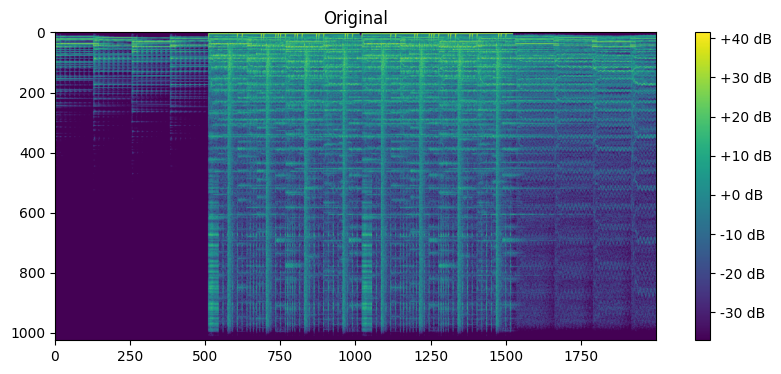

In [29]:
original = train_loader.dataset[10]
original = original.unsqueeze(0).to(device)
original_input = original.permute(0, 2, 1)  # (1, 2000, 1025)
reconstructed, mu, logvar = model_rnn(original_input)  # 👈 changement ic
original = original.squeeze(0).cpu().detach().numpy()
reconstructed = reconstructed.permute(0, 2, 1)
reconstructed = reconstructed.squeeze(0).cpu().detach().numpy()
original = denormalization(original, minim, maxim)
reconstructed = denormalization(reconstructed, minim, maxim)
print(original.shape)
plt.figure(figsize=(10, 4))
plt.imshow(original)
plt.title("Original")
plt.colorbar(format='%+2.0f dB')


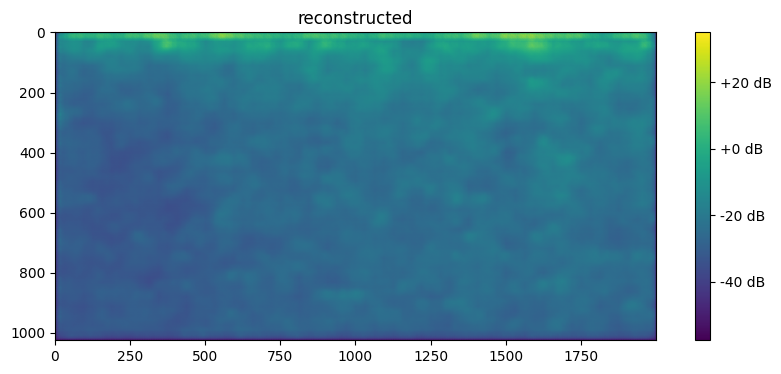

In [31]:
plt.figure(figsize=(10, 4))
plt.imshow(reconstructed.T)
plt.title("reconstructed")
plt.colorbar(format='%+2.0f dB')

In [ ]:
path = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\images_Rnn_VAE\\generation"
for index,im in enumerate(images):
    sample = im.unsqueeze(0).to(device)

    sample = sample.permute(0, 2, 1) 

    sample = sample.squeeze(0).cpu().detach().numpy()

   
    sample = denormalization(sample, minim, maxim)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(sample, y_axis='log', x_axis='time')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Generated Spectrogram {index}")
    img_path = os.path.join(path, f"generated_image{index}.png")
    plt.savefig(img_path)
    plt.close()
    audio_path = os.path.join(path, f"audio_generer{index}.wav")
    spec_amp = librosa.db_to_amplitude(sample)
    signal = librosa.griffinlim(spec_amp, hop_length=512)
    sf.write(audio_path, signal, 22050)

    


RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

In [ ]:
# a faire : verifier sample gerer pb explosion essayer lstm monter dim espace latent 
# essayer de generer au moins 1 son potable et essayer transformer 